## Group No 56

## Group Member Names:
### 1.AMIT KUMAR SRIVASTAVA
### 2.MRUNAL MADHUKAR AHIRE
### 3.PRAKASH PRASAD
### 4.RITESH RANJAN

## Problem Statement 3
### Edge-based Image Retrieval
### **Objective:** Implement an image retrieval system that uses edge-based features to find similar images in a dataset. Evaluate the retrieval performance using relevant metrics.

### Dataset from Caltech 101 Dataset https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip?download=1

# 1. Import the required libraries -- Score: 0.5 Mark

In [5]:
##---------Type the code below this line------------------##
## import os for all directory level activities and import random for random image selection  
import os
import random
## import cv2 for computer vision utils
import cv2
## import numpy and import pandas for dataframe level activies
import numpy as np
import pandas as pd
## import PIL for image based activies
from PIL import Image
## import sklearn for scikit-learn based utils like RandomForestClassifier, GridSearch, metrics 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
## import matplotlib for graph and image visualization 
import matplotlib.pyplot as plt
import shutil

# 2. Data Acquisition  -- Score: 1 Mark

For the problem identified by you, students have to find the data source themselves from any data source.

* Download the Caltech 101 dataset from the provided link: Caltech 101 Dataset: https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip?download=1
* Select any 5 categories from the dataset. Each category should have at least 50 images.
  * 5 categories selected are
    * ketch
    * dalmatian
    * bonsai
    * pizza
    * revolver
* Organize the selected categories into separate folders, with each folder containing the corresponding images.

## 2.1 Code for converting the above downloaded data into a form suitable for DL



In [2]:
##---------Type the code below this line------------------##
#!unzip caltech-101.zip
#!unzip -l caltech-101.zip
# caltech-101 is extracted for the five categories ketch, dalmatian, bonsai, pizza, revolver
# uncommented for execution, commented while debuging the code

!unzip caltech-101.zip "caltech-101/ketch/*" -d "./"
!unzip caltech-101.zip "caltech-101/dalmatian/*" -d "./"
!unzip caltech-101.zip "caltech-101/bonsai/*" -d "./"
!unzip caltech-101.zip "caltech-101/pizza/*" -d "./"
!unzip caltech-101.zip "caltech-101/revolver/*" -d "./"


Archive:  caltech-101.zip
  inflating: ./caltech-101/ketch/image_0001.jpg  
  inflating: ./caltech-101/ketch/image_0002.jpg  
  inflating: ./caltech-101/ketch/image_0003.jpg  
  inflating: ./caltech-101/ketch/image_0004.jpg  
  inflating: ./caltech-101/ketch/image_0005.jpg  
  inflating: ./caltech-101/ketch/image_0006.jpg  
  inflating: ./caltech-101/ketch/image_0007.jpg  
  inflating: ./caltech-101/ketch/image_0008.jpg  
  inflating: ./caltech-101/ketch/image_0009.jpg  
  inflating: ./caltech-101/ketch/image_0010.jpg  
  inflating: ./caltech-101/ketch/image_0011.jpg  
  inflating: ./caltech-101/ketch/image_0012.jpg  
  inflating: ./caltech-101/ketch/image_0013.jpg  
  inflating: ./caltech-101/ketch/image_0014.jpg  
  inflating: ./caltech-101/ketch/image_0015.jpg  
  inflating: ./caltech-101/ketch/image_0016.jpg  
  inflating: ./caltech-101/ketch/image_0017.jpg  
  inflating: ./caltech-101/ketch/image_0018.jpg  
  inflating: ./caltech-101/ketch/image_0019.jpg  
  inflating: ./caltech-1

## 2.1 Write your observations from the above.

1. Size of the dataset
2. Plot the distribution of the categories of the target / label.



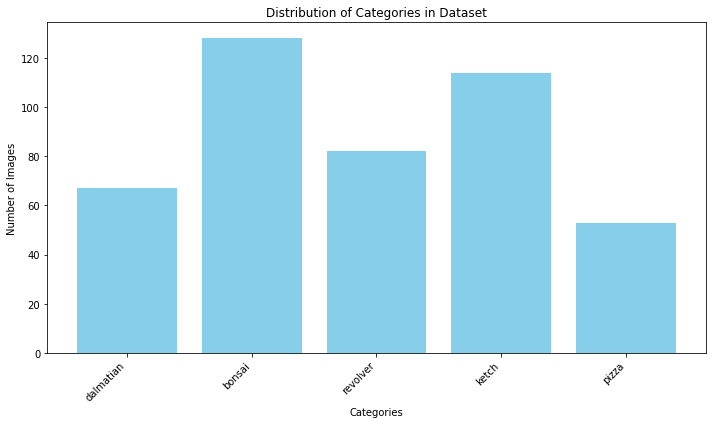

In [3]:
##--------------Type the answers below this line--------------##

def plot_category_distribution(dataset_path):
    # Get the list of categories
    categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    
    # Count the number of images in each category
    category_counts = {}
    for category in categories:
        if(category == ".ipynb_checkpoints"):
            pass
        else:
            category_path = os.path.join(dataset_path, category)
            category_counts[category] = len([f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))])
    
    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.bar(category_counts.keys(), category_counts.values(), color='skyblue')
    plt.xlabel('Categories')
    plt.ylabel('Number of Images')
    plt.title('Distribution of Categories in Dataset')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

dataset_path = './caltech-101/'
plot_category_distribution(dataset_path)

## ketch = 114 images
## dalmatian = 67 images
## bonsai = 128 images
## pizza = 53 images
## revolver = 82 images

## 3. Data Preparation -- Score: 3.5 Mark
### Perform the data preprocessing that is required for the data that you have downloaded.

## 3.1 Split the data into training set and testing set

In [6]:
##---------Type the code below this line------------------##
# Split in 80:20
# images are kept under training folder and test folder
# caltech-101/training/classes/images and caltech-101/test/classes/images
# read the directory for number of images in the dataset caltech-101/classes/images
# split it in 80:20, move the 80% images under training folder and 20% images under test folder

def count_images_in_folder(folder_path):
    image_files = []
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        try:
            with Image.open(file_path) as img:
                image_files.append(file_name)
        except (IOError, FileNotFoundError):
            # The file is not an image or it cannot be opened
            pass
    return image_files

def split_images(folder_path, train_folder, test_folder, split_ratio=0.8):
    image_files = count_images_in_folder(folder_path)
    random.shuffle(image_files)
    
    split_index = int(len(image_files) * split_ratio)
    train_images = image_files[:split_index]
    test_images = image_files[split_index:]
    
    if not os.path.exists(train_folder):
        os.makedirs(train_folder)
    if not os.path.exists(test_folder):
        os.makedirs(test_folder)
    
    for image in train_images:
        shutil.move(os.path.join(folder_path, image), os.path.join(train_folder, image))
    
    for image in test_images:
        shutil.move(os.path.join(folder_path, image), os.path.join(test_folder, image))
    
    print(f'Moved {len(train_images)} images to {train_folder}')
    print(f'Moved {len(test_images)} images to {test_folder}')


folder_path = 'caltech-101/ketch/'
train_folder = 'train/ketch/'
test_folder = 'test/ketch/'
split_images(folder_path, train_folder, test_folder)

folder_path = 'caltech-101/dalmatian/'
train_folder = 'train/dalmatian/'
test_folder = 'test/dalmatian/'
split_images(folder_path, train_folder, test_folder)

folder_path = 'caltech-101/bonsai/'
train_folder = 'train/bonsai/'
test_folder = 'test/bonsai/'
split_images(folder_path, train_folder, test_folder)

folder_path = 'caltech-101/pizza/'
train_folder = 'train/pizza/'
test_folder = 'test/pizza/'
split_images(folder_path, train_folder, test_folder)

folder_path = 'caltech-101/revolver/'
train_folder = 'train/revolver/'
test_folder = 'test/revolver/'
split_images(folder_path, train_folder, test_folder)


## Train
## ketch = 91 images
## dalmatian = 53 images
## bonsai = 102 images
## pizza = 42 images
## revolver = 66 images

## Test
## ketch = 23 images
## dalmatian = 14 images
## bonsai = 26 images
## pizza = 11 images
## revolver = 16 images

Moved 91 images to train/ketch/
Moved 23 images to test/ketch/
Moved 53 images to train/dalmatian/
Moved 14 images to test/dalmatian/
Moved 102 images to train/bonsai/
Moved 26 images to test/bonsai/
Moved 42 images to train/pizza/
Moved 11 images to test/pizza/
Moved 65 images to train/revolver/
Moved 17 images to test/revolver/


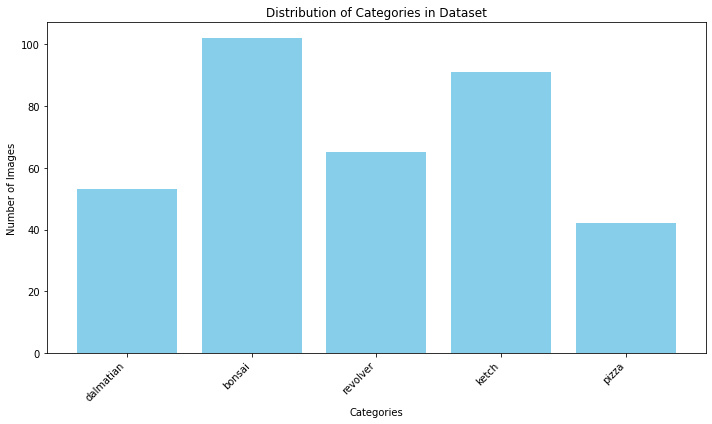

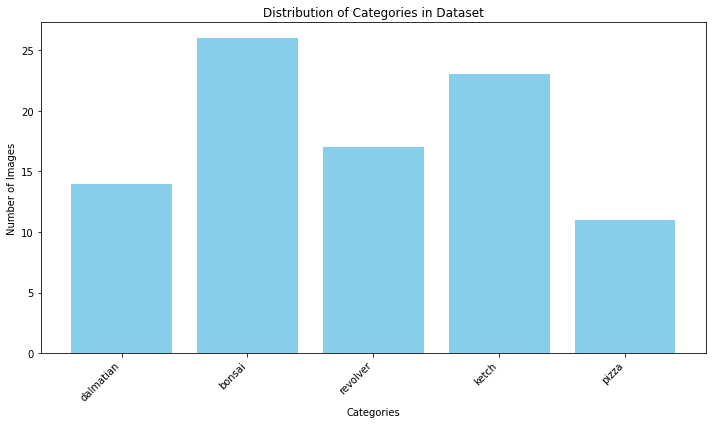

In [7]:
training_dataset_path = './train'
plot_category_distribution(training_dataset_path)
test_dataset_path = './test'
plot_category_distribution(test_dataset_path)

## 3.2 Preprocessing

### Preprocess the images as follows:
* Convert the images to grayscale.
* Apply the Canny edge detection algorithm to extract edges from the images.
* Extract edge-based descriptors such as edge histograms or gradient histograms from the preprocessed images.
* Create multiple feature sets by varying the parameters of the edge detection and descriptor extraction methods.
* Store the extracted features in separate dataframes, along with the corresponding category labels.
* Normalize the feature values using techniques like min-max scaling or z-score normalization.
* If the feature dimensionality is too high, apply dimensionality reduction techniques such as PCA or resize the images to a smaller fixed size.



In [45]:
##---------Type the answer below this line------------------##
'''
STEP1: Convert the images to grayscale.
STEP2: Canny edge detection is applied to the images.
STEP3: Extract edge-based descriptor using  gradient histograms.
STEP4: Multiple feature sets is created by varying the parameters of the 
       edge detection and descriptor extraction methods.
STEP5: Extracted features is stored in separate dataframes, along with the corresponding category labels.
STEP6: Normalize the feature values using techniques z-score normalization.
STEP7: Feature dimensionality is calculated
STEP8: Dimensionality reduction techniques PCA is applied.
'''
# STEP 1: Convert images to grayscale
def load_and_preprocess_images(directory):
    images = []
    labels = []
    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                file_path = os.path.join(label_path, file)
                image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                images.append(image)
                labels.append(label)
    return images, labels

# STEP 2: Apply Canny edge detection
def apply_canny_edge_detection(image, low_threshold, high_threshold):
    return cv2.Canny(image, low_threshold, high_threshold)

# STEP 3: Extract edge-based descriptor using gradient histograms
def extract_gradient_histograms(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    hist, _ = np.histogram(angle, bins=200, range=(0, 360), weights=magnitude)
    return hist

# STEP 4: Create multiple feature sets by varying parameters
def create_feature_sets(images, labels):
    feature_sets = []
    low_thresholds = [0, 100]
    high_thresholds = [150, 200]
    for low_threshold in low_thresholds:
        for high_threshold in high_thresholds:
            features = []
            for image in images:
                edges = apply_canny_edge_detection(image, low_threshold, high_threshold)
                hist = extract_gradient_histograms(edges)
                features.append(hist)
            feature_sets.append((pd.DataFrame(features), labels))
    return feature_sets

# STEP 5: Store extracted features in separate dataframes
def store_features_in_dataframes(feature_sets):
    dataframes = []
    for features, labels in feature_sets:
        df = pd.DataFrame(features)
        df['label'] = labels
        dataframes.append(df)
    return dataframes

# STEP 6: Normalize the feature values using z-score normalization
def normalize_features(dataframes):
    normalized_dataframes = []
    for df in dataframes:
        features = df.iloc[:, :-1]
        scaler = StandardScaler()
        normalized_features = scaler.fit_transform(features)
        normalized_df = pd.DataFrame(normalized_features)
        normalized_df['label'] = df['label'].values
        normalized_dataframes.append(normalized_df)
    return normalized_dataframes

# STEP 7: Calculate feature dimensionality
def calculate_feature_dimensionality(dataframes):
    for df in dataframes:
        print(f"Feature Dimensionality: {df.shape[1] - 1}")

# Load and preprocess images
training_images, training_labels = load_and_preprocess_images('./train')
test_images, test_labels = load_and_preprocess_images('./test')

# Create feature sets
feature_sets = create_feature_sets(training_images, training_labels)

# Store features in dataframes
dataframes = store_features_in_dataframes(feature_sets)

# Normalize features
normalized_dataframes = normalize_features(dataframes)

# Calculate feature dimensionality
calculate_feature_dimensionality(normalized_dataframes)

Feature Dimensionality: 200
Feature Dimensionality: 200
Feature Dimensionality: 200
Feature Dimensionality: 200


Category: dalmatian
0 150


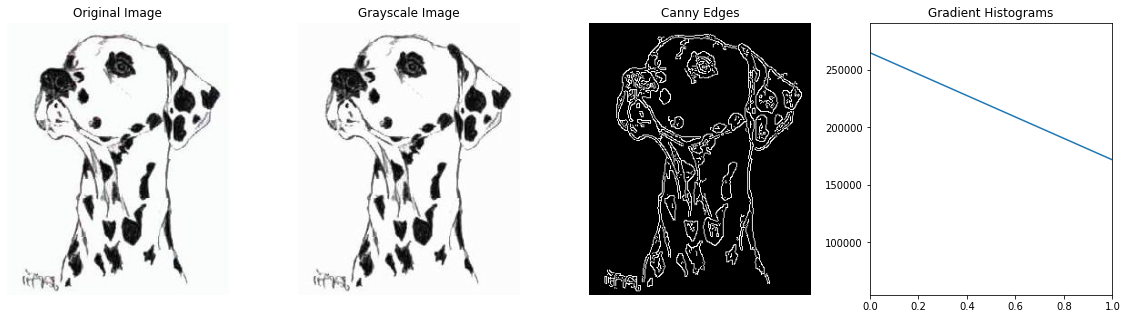

100 200


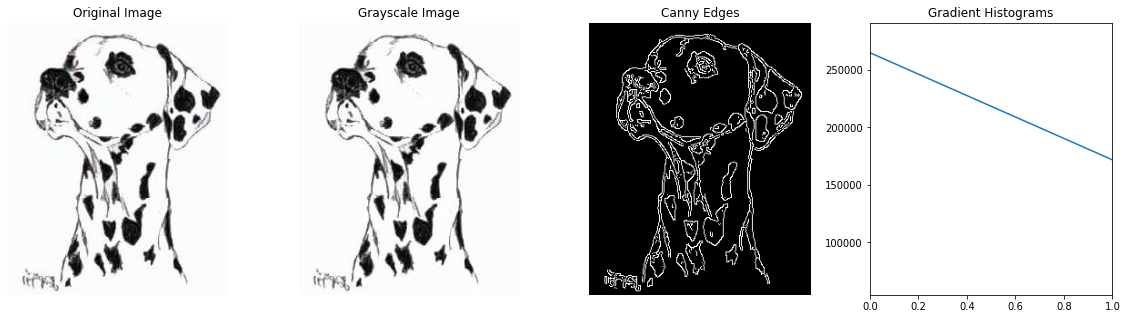

Category: bonsai
0 150


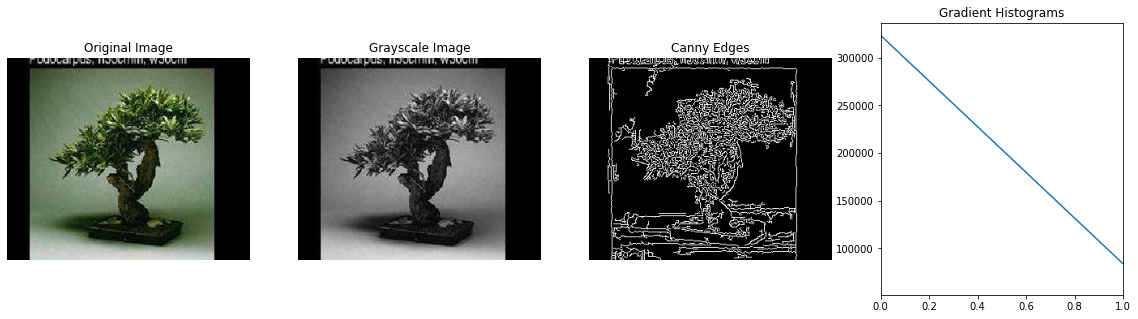

100 200


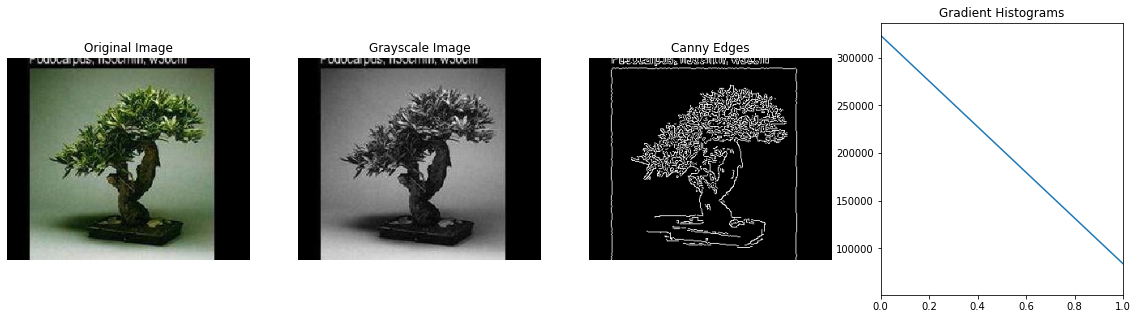

Category: revolver
0 150


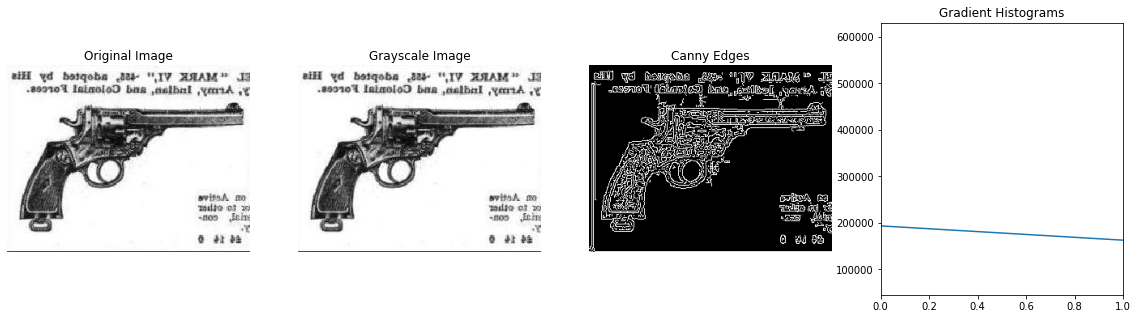

100 200


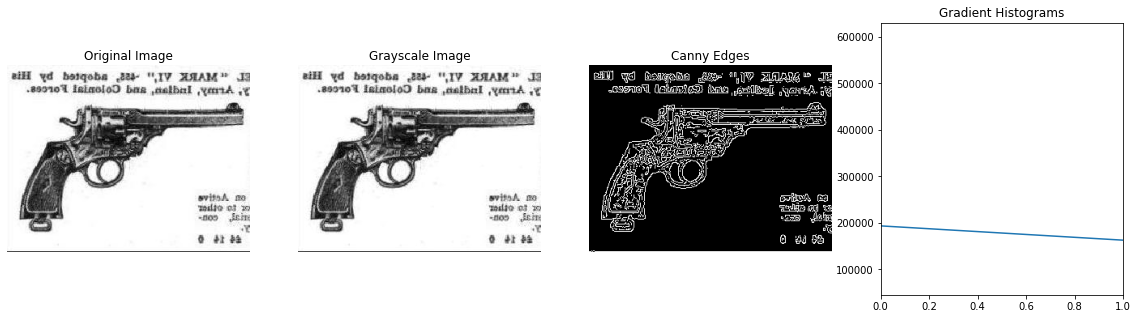

Category: ketch
0 150


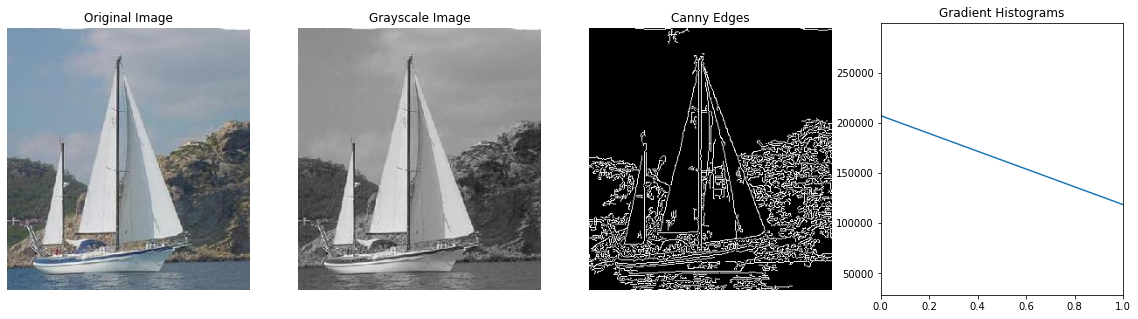

100 200


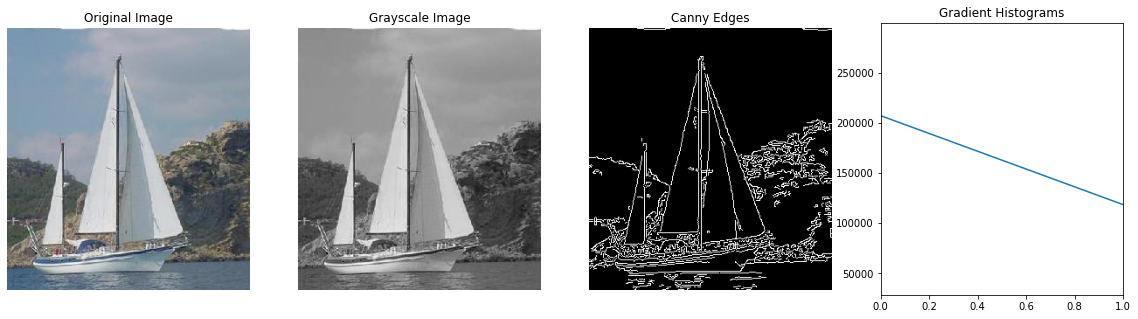

Category: pizza
0 150


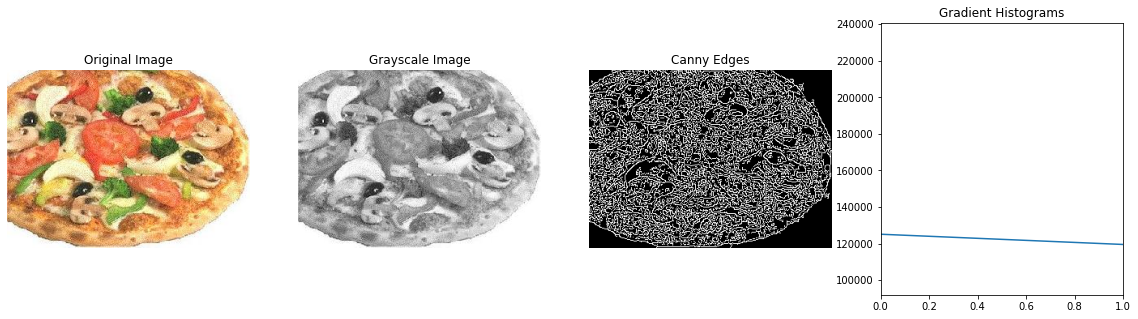

100 200


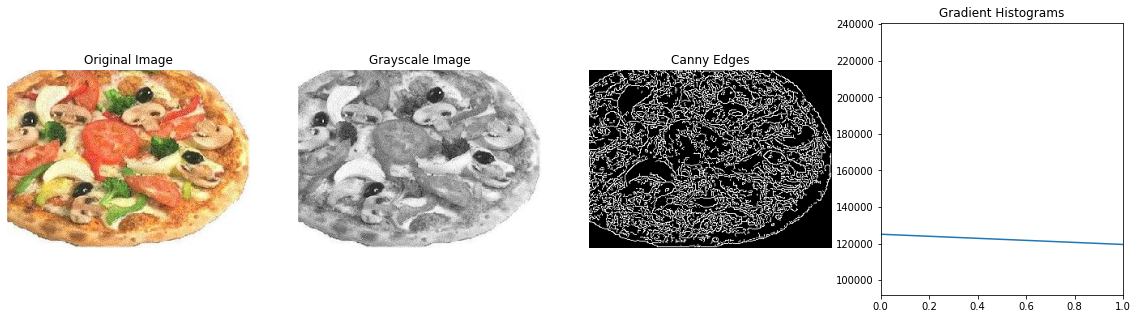

In [40]:
# Visualization function
low_thresholds = [0, 100]
high_thresholds = [150, 200]
def visualize_image_processing(image_path, low_threshold, high_threshold):
    image = cv2.imread(image_path)
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    edges = apply_canny_edge_detection(gray_image, low_threshold, high_threshold)
    hist = extract_gradient_histograms(gray_image)
    
    # Plot the original, grayscale, edge-detected images and histogram
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title('Grayscale Image')
    plt.imshow(gray_image, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title('Canny Edges')
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title('Gradient Histograms')
    plt.plot(hist)
    plt.xlim([0, 1])
    
    plt.show()

# Visualize processing steps for a random training image from each category
training_dir = "./train"
categories = os.listdir(training_dir)
for category in categories:
    category_path = os.path.join(training_dir, category)
    if os.path.isdir(category_path):
        image_name = random.choice(os.listdir(category_path))
        image_path = os.path.join(category_path, image_name)
        print(f"Category: {category}")
        for low, high in zip(low_thresholds, high_thresholds):
            print(low,high)
            visualize_image_processing(image_path, low, high)

# 4.1 Model Building - Score: 2 Marks
* Select a classical machine learning algorithm such as Support Vector Machines (SVM), Random Forest, or XGBoost for training the image retrieval model.
* Train the chosen model on different feature combinations created in the preprocessing step.
* Use appropriate hyperparameter tuning techniques (e.g., grid search, random search) and cross-validation (e.g., k-fold) to optimize the model's performance.

In [46]:
##---------Type the code below this line------------------##
# Train and evaluate the Random Forest model
results = []
for df in normalized_dataframes:
    X = df.iloc[:, :-1]
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Hyperparameter tuning using Grid Search
    param_grid = {'n_estimators': [50, 100, 150, 200], 'max_depth': [None, 10, 20, 30, 40, 50]}
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    
    # Cross-validation
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
    
    # Evaluate on the test set
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Mean Average Precision
    y_scores = best_model.predict_proba(X_test)
    map_score = average_precision_score(y_test, y_scores, average='weighted')
    
    results.append({
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'map_score': map_score,
        'model': best_model
    })

# Select the best model based on F1 score
best_result = max(results, key=lambda x: x['f1_score'])
best_model = best_result['model']

## 4.2 Validation matrix - 1 Mark

###Evaluate the trained models using the following metrics: 
* Accuracy
* Precision
* Recall
* F1 score
* Mean Average Precision (mAP)
* Calculate the mAP by ranking the retrieved images based on their similarity scores and computing the average precision at different recall levels.
* Aim for a minimum mAP of 0.7 to consider the retrieval system as acceptable.


In [47]:
##---------Type the answer below this line------------------##
## The validation matrix is also defined above in the training loop for training evaluation   
'''
    # Hyperparameter tuning using Grid Search
    param_grid = {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20, 30]}
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    
    # Cross-validation
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
    
    # Evaluate on the test set
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Mean Average Precision
    y_scores = best_model.predict_proba(X_test)
    map_score = average_precision_score(y_test, y_scores, average='weighted')
'''
print("Accuracy, Precision, Recall, f1_score, map_score")
results

Accuracy, Precision, Recall, f1_score, map_score


[{'accuracy': 0.6619718309859155,
  'precision': 0.7012247397428047,
  'recall': 0.6619718309859155,
  'f1_score': 0.6588910083879902,
  'map_score': 0.7128051840815269,
  'model': RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)},
 {'accuracy': 0.6056338028169014,
  'precision': 0.708806373595106,
  'recall': 0.6056338028169014,
  'f1_score': 0.613528663620519,
  'map_score': 0.7257054277177767,
  'model': RandomForestClassifier(max_depth=10, n_estimators=150, random_state=42)},
 {'accuracy': 0.647887323943662,
  'precision': 0.7258938244853738,
  'recall': 0.647887323943662,
  'f1_score': 0.636800323471932,
  'map_score': 0.7634459181400646,
  'model': RandomForestClassifier(random_state=42)},
 {'accuracy': 0.6056338028169014,
  'precision': 0.6781223131498697,
  'recall': 0.6056338028169014,
  'f1_score': 0.6063751196460494,
  'map_score': 0.79739277165896,
  'model': RandomForestClassifier(max_depth=10, n_estimators=150, random_state=42)}]

# 5.1 Model Inference - 2 Mark

* Randomly select 5 test images from each category and use the best-performing model to retrieve the top-5 most similar images for each query image.
* Display the query image along with its top-5 retrieved images, their predicted labels, and the actual labels.

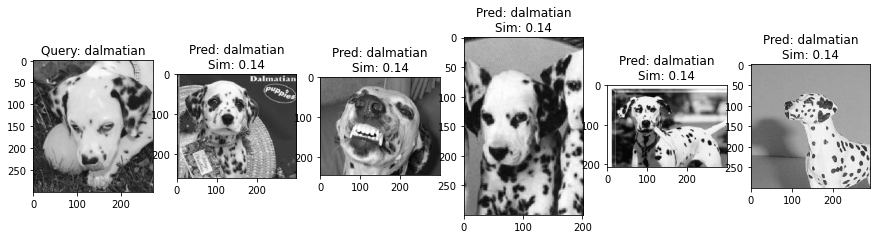

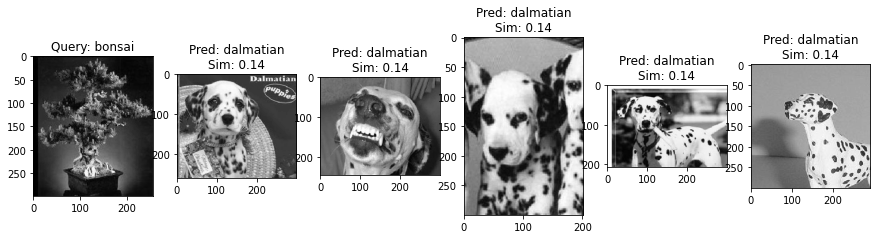

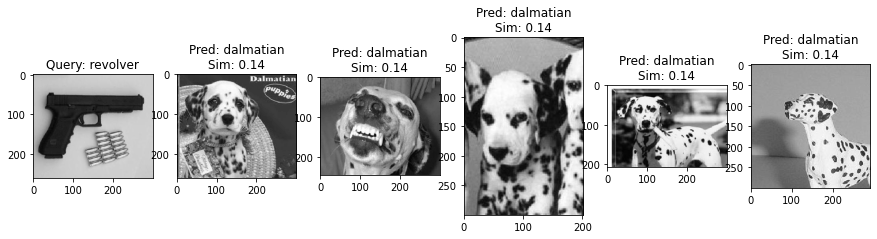

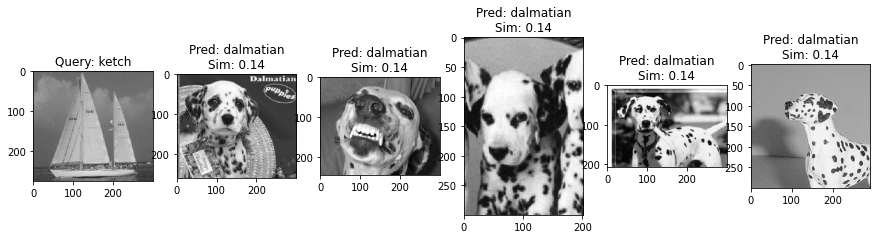

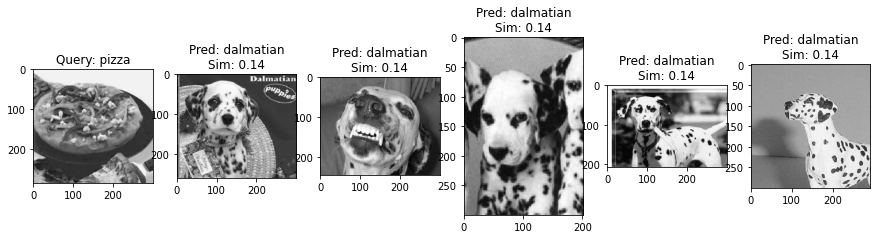

In [53]:
# Function to retrieve similar images for a given query image
def retrieve_similar_images(model, query_image, training_images, training_labels):
    query_edges = apply_canny_edge_detection(query_image, 100, 200)
    query_hist = extract_gradient_histograms(query_edges)
    query_features = np.array(query_hist).reshape(1, -1)

    training_features = []
    for train_image in training_images:
        train_edges = apply_canny_edge_detection(train_image, 100, 200)
        train_hist = extract_gradient_histograms(train_edges)
        train_features = np.array(train_hist).reshape(1, -1)
        training_features.append(train_features)
    
    training_features = np.vstack(training_features)
    query_similarity_scores = model.predict_proba(training_features)[:, 1]  
    #print("query_similarity_scores",query_similarity_scores)

    similarities = list(zip(query_similarity_scores, training_images, training_labels))
    similarities.sort(reverse=True, key=lambda x: x[0])
    top_5 = similarities[:5]

    return top_5

# Function to randomly select 5 test images from each category and retrieve top-5 similar images
def display_retrieved_images(model, test_images, test_labels, training_images, training_labels):
    category_indices = {}
    for idx, label in enumerate(test_labels):
        if label not in category_indices:
            category_indices[label] = []
        category_indices[label].append(idx)

    for category, indices in category_indices.items():
        selected_indices = random.sample(indices, min(1, len(indices)))
        for i in selected_indices:
            query_image = test_images[i]
            query_label = test_labels[i]

            top_5 = retrieve_similar_images(model, query_image, training_images, training_labels)

            plt.figure(figsize=(15, 5))
            plt.subplot(1, 6, 1)
            plt.imshow(query_image, cmap='gray')
            plt.title(f"Query: {query_label}")

            for j, (similarity, top_image, top_label) in enumerate(top_5):
                plt.subplot(1, 6, j+2)
                plt.imshow(top_image, cmap='gray')
                plt.title(f"Pred: {top_label}\nSim: {similarity:.2f}")

            plt.show()

# Retrieve and display top-5 similar images for randomly selected test images from each category
display_retrieved_images(best_model, test_images, test_labels, training_images, training_labels)

* Justify your choice of features based on the retrieval performance and visual analysis of the results.
* Analyze the retrieval results and discuss the effectiveness of the edge-based features for image retrieval.
* Compare the performance of different feature combinations and highlight the ones that yield the best results.
* Identify any limitations or challenges encountered during the implementation and suggest potential improvements or alternative approaches.


In [ ]:
##---------Type the answers below this line------------------##
##
## Justify your choice of features based on the retrieval performance and visual analysis of the results.
## retrieval performance is not good, the features selected are 200 but still classification is not giving the result
## The classification f1 score is .65, which is not below the expectation but still some retrival should be possible.
## The different features used for different threshold, the best model is choosen on the basis of the f1 score
## Limitation is edge only based classification, if the same is applied on gray image, better image is expected
##

### NOTE


All Late Submissions will incur a <b>penalty of -2 marks </b>. So submit your assignments on time.

Good Luck